In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from lib.readwav import *

# Organ


In [2]:
# First of all, we read the audio file using the given function readwav:
filename = "./wav_files/note_1.wav"
rate, data = readwav(filename)
# The way it is implemented, readwaw reads a wav file and returns two things:
# a float that contains the sampling rate of the signal,
# and an array that contains the actual data, meaning the intensity of the signal.
# The array is a matrix with two columns if the audio file was originally stereo instead of mono, so each column is a channel.
# The function manages to handle both 8bit signals and 24bit signals

# Let's print the rate of the chosen file:
print(rate) # the measure unit is Hertz

# Let's check whether the file was stereo or mono:
print(data.shape) # either there is no second column (mono) or there are two columns (stereo)

time = np.linspace(0, data.shape[0], data.shape[0], endpoint = False) # just a counter index for now
print(time)
time /= rate # Measure unit is now seconds

48000
(332193, 2)
[0.00000e+00 1.00000e+00 2.00000e+00 ... 3.32190e+05 3.32191e+05
 3.32192e+05]


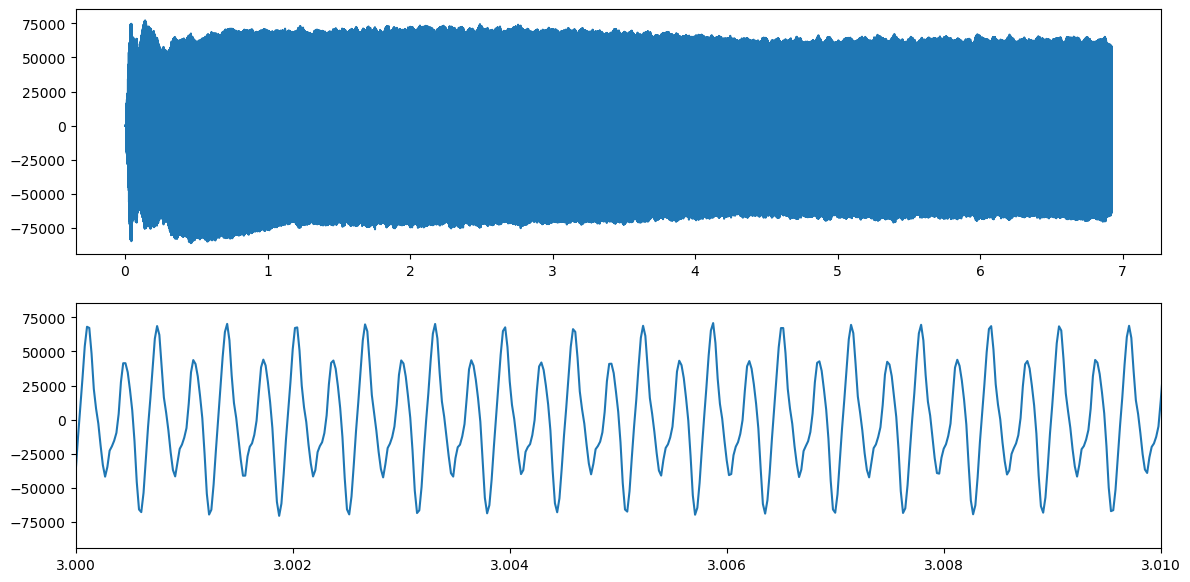

In [3]:
# Let's try visualizing the actual signal to get an idea:
figure, axes = plt.subplots(2, 1, figsize=(14, 7))
ax = axes[0]
ax.plot(time, data[:,0])

ax = axes[1]
ax.plot(time, data[:,0])
ax.set_xlim(3.0, 3.01)

plt.show()

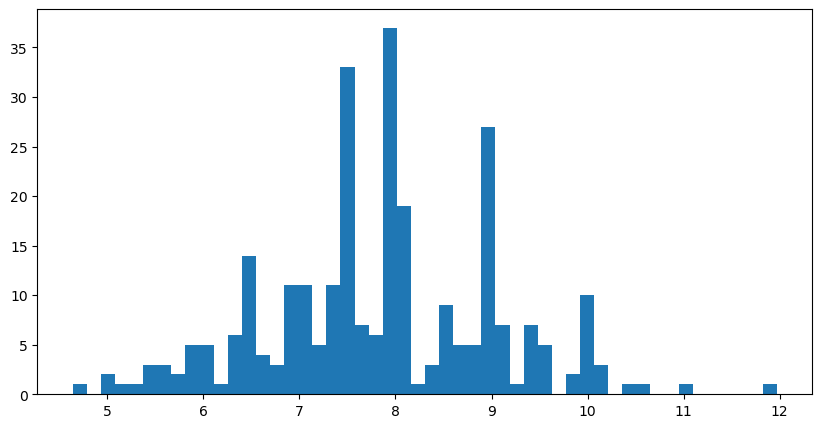

In [4]:
# Now we are curios to see the distribution of lengths of the signals, in the sense that we wonder if they're all
# 7 seconds long or something.

lengths = []
for i in range(1, 281):
    filename = "./wav_files/note_{}.wav".format(i)
    rate, data = readwav(filename)
    time = np.linspace(0, data.shape[0], data.shape[0], endpoint = False)
    time /= rate
    lengths.append(np.max(time))

plt.figure(figsize = (10, 5))
plt.hist(lengths, bins=50)
plt.show()
# Lengths go from 4s to 12s excluded, let's say

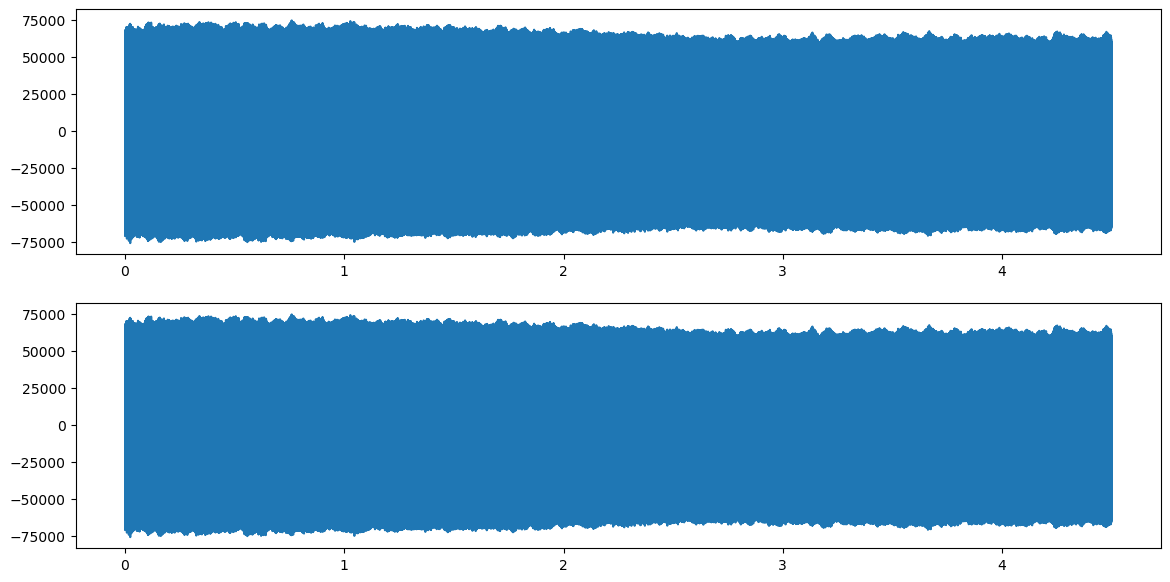

In [5]:
# taglio il segnale togliendo il primo 25% e l'ultimo 10 %
def cut_signal(signal):
    start = int(0.25 * signal.shape[0])
    end = int(0.9 * signal.shape[0])
    return signal[start:end]

#visualizzo il file tagliato
filename = "./wav_files/note_1.wav"
rate, data = readwav(filename)
data = cut_signal(data)
time = np.linspace(0, data.shape[0], data.shape[0], endpoint = False)
time /= rate    
figure, axes = plt.subplots(2, 1, figsize=(14, 7))
ax = axes[0]
ax.plot(time, data[:,0])
ax = axes[1]
ax.plot(time, data[:,0])
plt.show()

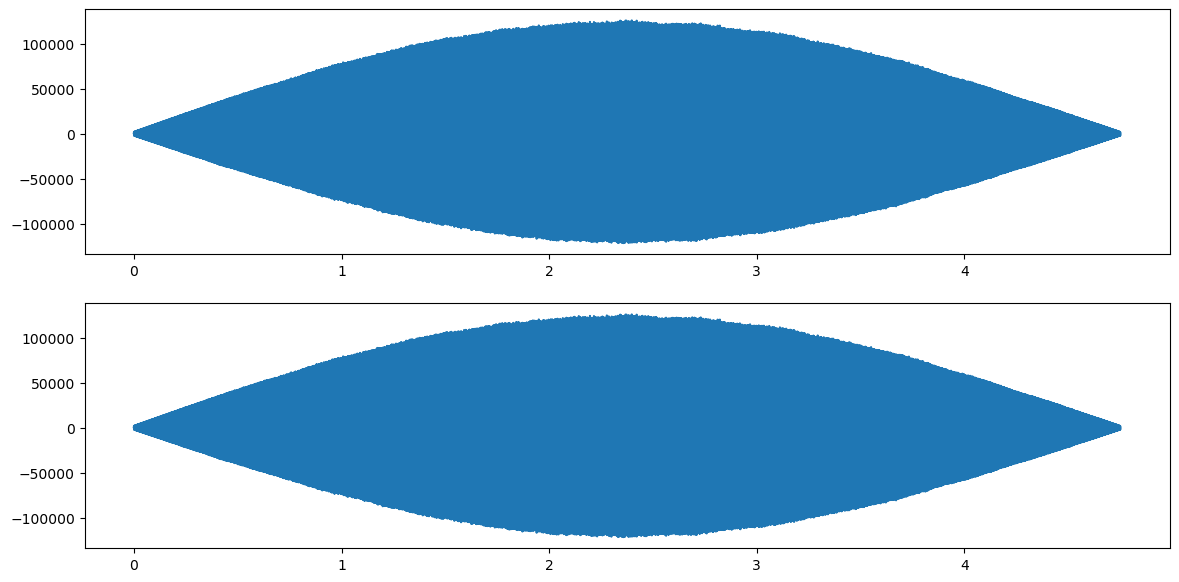

In [18]:
# Implementiamo la finestra gaussiana da applicare al segnale, in modo da attenuare i bordi e rendere più evidenti i picchi
def gaussian_window(signal, sigma):
    n = signal.shape[0]
    x = np.arange(n)
    center = n / 2
    window = np.exp(-0.5 * ((x - center) / sigma) ** 2) - 0.6
    return signal * window[:, np.newaxis]

# Applichiamo la finestra gaussiana al segnale tagliato
filename = "./wav_files/note_100.wav"
rate, data = readwav(filename)
data = cut_signal(data)

sigma = data.shape[0]/2
data_gaussian = gaussian_window(data, sigma)

# Visualizziamo il segnale con la finestra gaussiana
time = np.linspace(0, data_gaussian.shape[0], data_gaussian.shape[0], endpoint = False)
time /= rate
figure, axes = plt.subplots(2, 1, figsize=(14, 7))
ax = axes[0]
ax.plot(time, data_gaussian[:,0])
ax = axes[1]
ax.plot(time, data_gaussian[:,0])
plt.show()




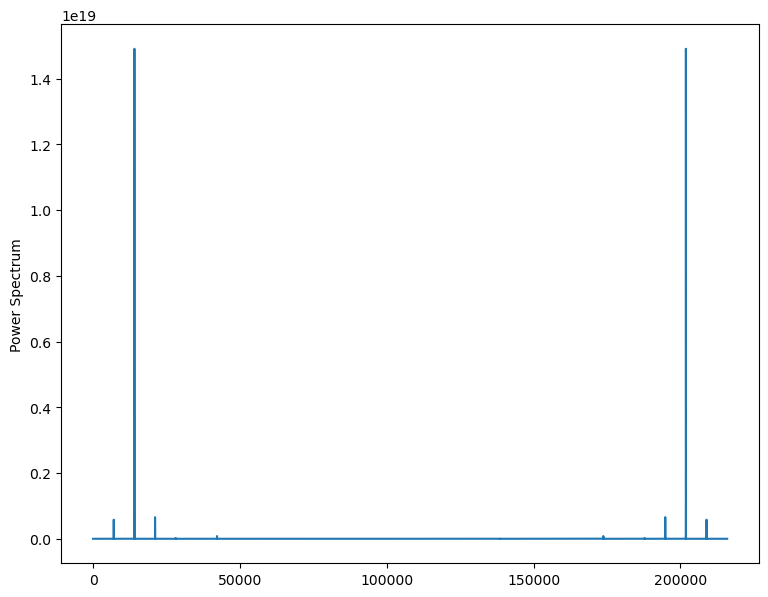

In [7]:
# facciamo la fft del segnale tagliato
fft = np.fft.fft(data[:,0])
frequencies = np.fft.fftfreq(data.shape[0], 1/rate)
plt.figure(figsize=(9, 7))
#plt.plot(frequencies, np.abs(fft))


array_indexes = np.linspace(0, np.abs(fft).shape[0], np.abs(fft).shape[0], endpoint = False)

#calcolo power spectrum
power_spectrum = np.abs(fft)**2
plt.plot(array_indexes, power_spectrum)
plt.xlabel("")
plt.ylabel("Power Spectrum")
#plt.plot(array_indexes, np.abs(fft))
#plt.xlabel("Frequency (Hz)")
#plt.ylabel("Magnitude")

plt.show()